In [78]:
import os
import sys
import json
import numpy as np
sys.path.append("../")
from modules.utils import(get_video_metadata, get_cropped_video_indices, load_splits_cropped, ALIGN_DIR)
from scipy.spatial.distance import pdist

In [ ]:
metadata_files = get_video_metadata("/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align")
LANDMARKS_DIR = "/Users/christina/code/RockPaperScissors_backup/my_rps_dataset/features_img/features_coords"

features_per_class = {"rock": [], "paper": [], "scissors": []}

for meta_file in metadata_files:
    with open(meta_file, "r") as f:
        data = json.load(f)
    start, onset, end, _ = get_cropped_video_indices(data)

    vid_name = meta_file.split('/')[-2]
    landmarks_file = os.path.join(LANDMARKS_DIR, f"{vid_name}_landmarks.npz")
    landmarks_data = np.load(landmarks_file, allow_pickle=True)
    landmarks = landmarks_data["landmarks"][start:end+1]
    print(f"Number of NaN frames in {vid_name}: {[np.isnan(landmarks[i]).all() for i in range(landmarks.shape[0])].count(True)}")
    label = data.get("label")
    features_per_class[label].append((landmarks.reshape(-1, 63), vid_name))


paper: 11 image files
['/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_49/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_38/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_36/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_31/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_37/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_45/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_20/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_35/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_50/metadata.json', '/Users/christina/code/RockPaper

(10, 13, 63)


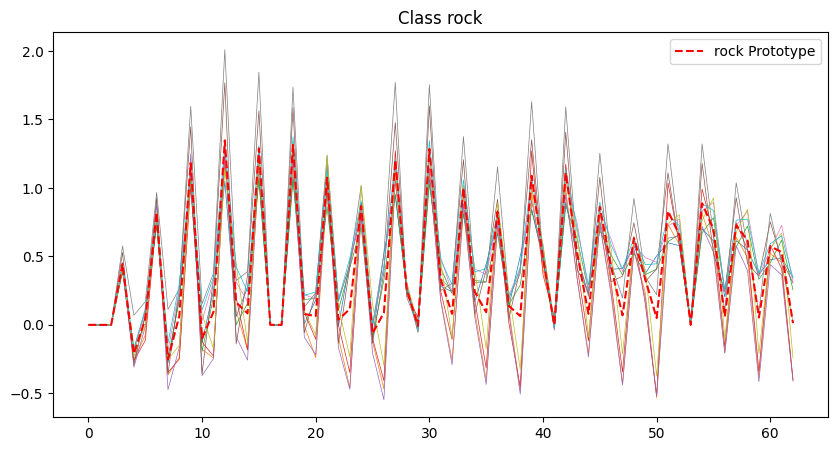

Prototype sample for class rock: rock_47
(10, 13, 63)


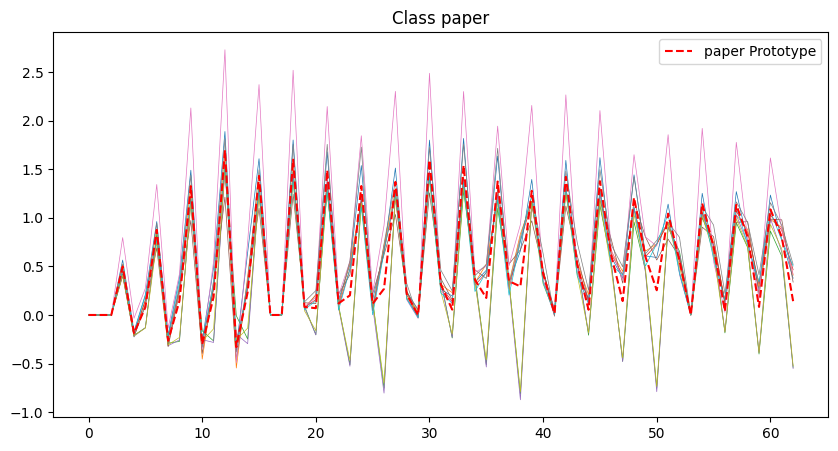

Prototype sample for class paper: paper_31
(10, 13, 63)


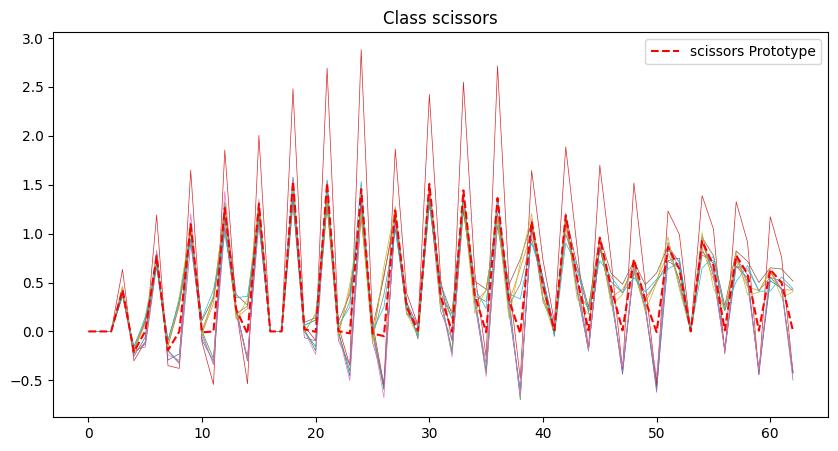

Prototype sample for class scissors: scissors_32


In [ ]:
import matplotlib.pyplot as plt

def dist_from_prototype(prototype , sample):  
    d = np.linalg.norm(prototype - sample)
    return d
    
for gesture_class in ["rock", "paper", "scissors"]:
    # all_features = np.stack(features_per_class[gesture_class])
    all_features = np.stack([features_per_class[gesture_class][i][0] for i in range(len(features_per_class[gesture_class]))])
    N_CLASS_SAMPLES = all_features.shape[0]
    print(all_features.shape)

    avg_features_per_sample = np.apply_along_axis(np.nanmean, 1, all_features)
    avg_features_prototype = avg_features_per_sample.mean(axis=0)
    avg_features_per_sample.shape, avg_features_prototype.shape

    plt.figure(figsize=(10, 5))
    plt.title(f"Class {gesture_class}")
    for i in range(avg_features_per_sample.shape[0]):
        plt.plot(avg_features_per_sample[i], alpha=1, linewidth=0.5)
    plt.plot(avg_features_prototype, label=f"{gesture_class} Prototype", linestyle="--", color='red')
    plt.xlabel("Landmark Index")
    plt.ylabel("Mean Value Across Frames")
    plt.legend()
    plt.show()
    # Find min distance and return index of closest sample to prototype
    distances = np.apply_along_axis(dist_from_prototype, 1, avg_features_per_sample, avg_features_prototype)
    prototype_sample_idx = np.argmin(distances).item()
    print(f"Prototype sample for class {gesture_class}: {features_per_class[gesture_class][prototype_sample_idx][1]}")

In [95]:
data = np.load("/Users/christina/code/RockPaperScissors/my_rps_dataset/landmarks/rock_23_landmarks.npz")
# data = np.load("/Users/christina/code/RockPaperScissors_backup/my_rps_dataset/landmarks_img/rock_23_landmarks.npz")
l = data["landmarks"]

In [96]:
l.shape

(60, 63)

In [94]:
for i in range(l.shape[0]):
    if np.isnan(l[i]).all():
        print(f"Frame {i} is NaNs")

Frame 0 is NaNs
Frame 1 is NaNs
Frame 2 is NaNs
Frame 3 is NaNs
Frame 4 is NaNs
Frame 5 is NaNs
Frame 6 is NaNs
Frame 7 is NaNs
Frame 8 is NaNs
Frame 9 is NaNs
Frame 10 is NaNs
Frame 11 is NaNs
Frame 12 is NaNs
Frame 13 is NaNs
Frame 14 is NaNs
Frame 15 is NaNs
Frame 16 is NaNs
Frame 17 is NaNs
Frame 18 is NaNs
Frame 19 is NaNs
Frame 20 is NaNs
Frame 21 is NaNs
Frame 22 is NaNs
Frame 23 is NaNs
Frame 24 is NaNs
Frame 25 is NaNs
Frame 26 is NaNs
Frame 27 is NaNs
Frame 28 is NaNs
Frame 29 is NaNs
Frame 30 is NaNs
Frame 31 is NaNs
Frame 32 is NaNs
Frame 33 is NaNs
Frame 34 is NaNs
Frame 35 is NaNs
Frame 36 is NaNs
Frame 37 is NaNs
Frame 38 is NaNs
Frame 39 is NaNs
Frame 40 is NaNs
Frame 41 is NaNs
Frame 42 is NaNs
Frame 43 is NaNs
Frame 44 is NaNs
Frame 45 is NaNs
Frame 46 is NaNs
Frame 47 is NaNs
Frame 48 is NaNs
Frame 49 is NaNs
Frame 50 is NaNs
Frame 51 is NaNs
Frame 52 is NaNs
Frame 53 is NaNs
Frame 54 is NaNs
Frame 55 is NaNs
Frame 56 is NaNs
Frame 57 is NaNs
Frame 58 is NaNs
Frame 5